In [1]:
import networkx as nx
from langchain_ollama import ChatOllama
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser

# 1. Load Local LLM
# Temperature=0 is crucial here. We want facts, not creativity.
llm = ChatOllama(model="mistral", temperature=0)

In [2]:
# 2. Prompt for Extracting Graph Triples
extract_prompt = PromptTemplate(
    template="""
You are an expert knowledge graph builder.
Extract entities and relationships from the text.
Return ONLY a JSON list. Each item must contain:
- "head": source entity
- "relation": relationship
- "tail": target entity

Text:
{text}

Output JSON:
""",
    input_variables=["text"],
)

extraction_chain = extract_prompt | llm | JsonOutputParser()

In [3]:
# 3. Enterprise Knowledge Example
company_text = """
OpenAI was founded by Sam Altman and Elon Musk.
OpenAI developed GPT-4.
GPT-4 powers ChatGPT.
Microsoft partnered with OpenAI.
Microsoft invested 10 billion dollars in OpenAI.
ChatGPT is used by millions of users worldwide.
"""

print("\n Extracting knowledge graph triples...\n")
triples = extraction_chain.invoke({"text": company_text})
print(triples)


 Extracting knowledge graph triples...

[{'head': 'OpenAI', 'relation': 'founded_by', 'tail': 'Sam Altman'}, {'head': 'OpenAI', 'relation': 'founded_by', 'tail': 'Elon Musk'}, {'head': 'OpenAI', 'relation': 'developed', 'tail': 'GPT-4'}, {'head': 'GPT-4', 'relation': 'powers', 'tail': 'ChatGPT'}, {'head': 'OpenAI', 'relation': 'partnered_with', 'tail': 'Microsoft'}, {'head': 'Microsoft', 'relation': 'invested_in', 'tail': 'OpenAI'}, {'head': 'Microsoft', 'relation': 'invested_amount', 'tail': '10 billion dollars'}, {'head': 'ChatGPT', 'relation': 'used_by', 'tail': 'millions of users worldwide'}]


In [5]:
kg = nx.DiGraph() # DiGraph means "Directed Graph" (arrows point one way)

def build_knowledge_graph(triples):
    for item in triples:
        head = item.get("head")
        tail = item.get("tail")
        relation = item.get("relation")

        if head and tail:
            kg.add_node(head)
            kg.add_node(tail)
            kg.add_edge(head, tail, label=relation)

build_knowledge_graph(triples)

print("\n Nodes in Graph:")
print(list(kg.nodes()))
print(list(kg.edges()))


 Nodes in Graph:
['OpenAI', 'Sam Altman', 'Elon Musk', 'GPT-4', 'ChatGPT', 'Microsoft', '10 billion dollars', 'millions of users worldwide']
[('OpenAI', 'Sam Altman'), ('OpenAI', 'Elon Musk'), ('OpenAI', 'GPT-4'), ('OpenAI', 'Microsoft'), ('GPT-4', 'ChatGPT'), ('ChatGPT', 'millions of users worldwide'), ('Microsoft', 'OpenAI'), ('Microsoft', '10 billion dollars')]


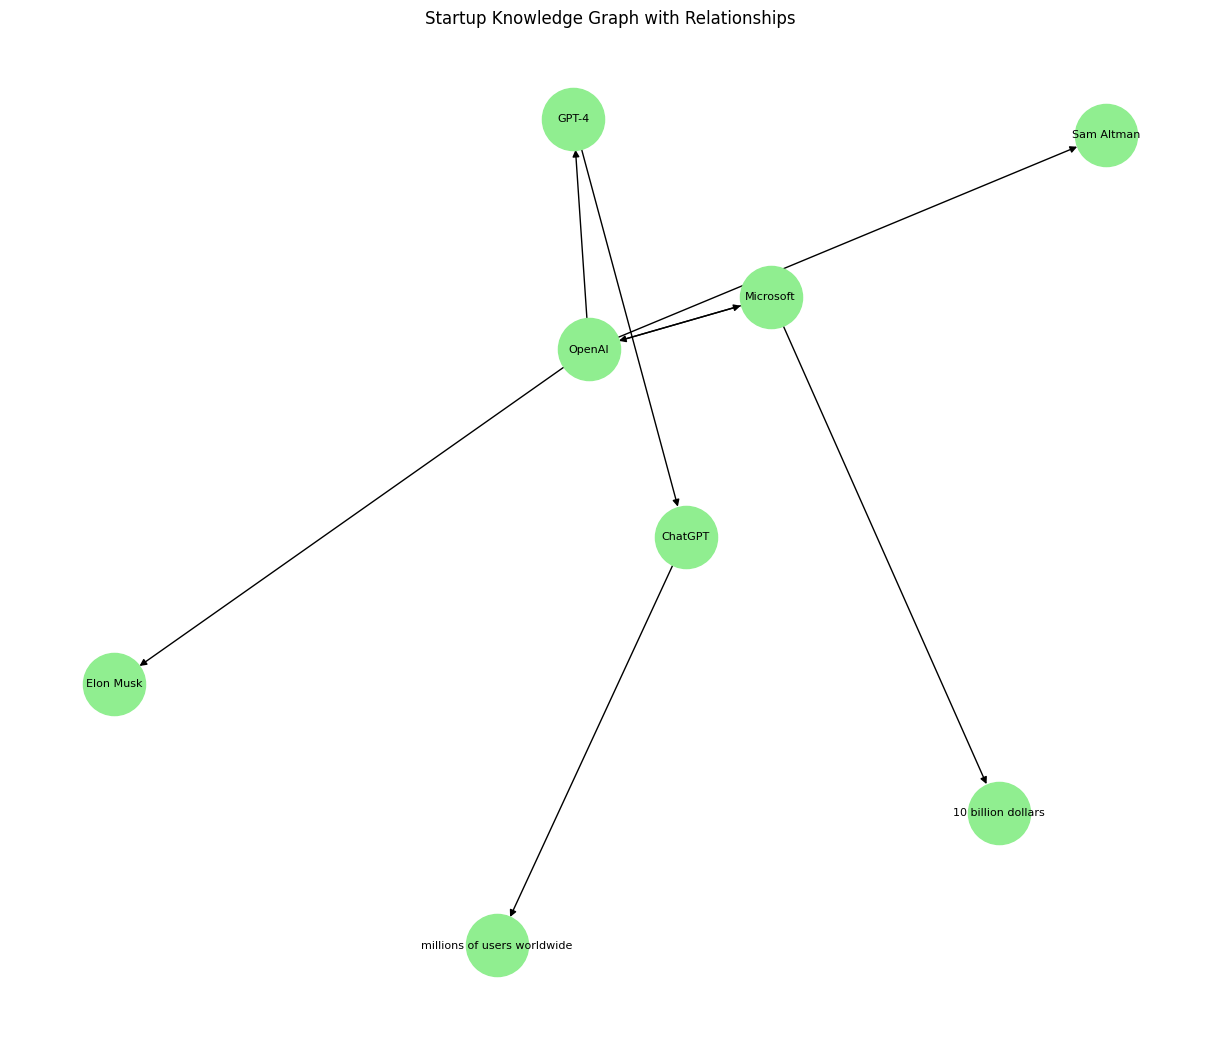

In [10]:
import matplotlib.pyplot as plt
import networkx as nx
plt.figure(figsize=(12,10))

pos = nx.spring_layout(kg, k=.81 ,seed=42)

nx.draw(
    kg,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightgreen",
    font_size=8
)

edge_labels = nx.get_edge_attributes(kg, "relation")

nx.draw_networkx_edge_labels(
    kg,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("Startup Knowledge Graph with Relationships")

plt.show()

In [40]:
def retrieve_full_graph_context(entity):
    context = set()
    visited_nodes = set()

    def dfs(node):
        visited_nodes.add(node)

        # Outgoing edges
        for neighbor in kg.successors(node):
            relation = kg.get_edge_data(node, neighbor)["label"]
            context.add(f"{node} {relation} {neighbor}")
            if neighbor not in visited_nodes:
                dfs(neighbor)

        # Incoming edges
        for predecessor in kg.predecessors(node):
            relation = kg.get_edge_data(predecessor, node)["label"]
            context.add(f"{predecessor} {relation} {node}")
            if predecessor not in visited_nodes:
                dfs(predecessor)

    if entity in kg.nodes:
        dfs(entity)

    return ". ".join(context)

In [41]:
retrieve_graph_context('OpenAI')

'Microsoft invested_in OpenAI. GPT-4 powers ChatGPT. OpenAI founded_by Sam Altman. ChatGPT used_by millions of users worldwide. Microsoft invested_amount 10 billion dollars. OpenAI partnered_with Microsoft. OpenAI developed GPT-4. OpenAI founded_by Elon Musk'

In [42]:
# 6. Final RAG Prompt
final_prompt = PromptTemplate(
    template="""
Answer the question using ONLY the context below.

Context:
{context}

Question:
{question}

Answer:
""",
    input_variables=["context", "question"]
)

rag_chain = final_prompt | llm

# 7. Ask a Multi-hop Reasoning Question
entity = "Microsoft"

# We ask for a depth of 3 to catch distant connections
graph_context = retrieve_graph_context(entity, max_depth=3) 

print("\n Retrieved Graph Context:\n")
print(graph_context)

question = "Which company invested in the company that built ChatGPT?"

response = rag_chain.invoke({
    "context": graph_context,
    "question": question
})

print("\n Final Answer:\n")
print(response.content)


 Retrieved Graph Context:

Microsoft invested_in OpenAI. GPT-4 powers ChatGPT. OpenAI founded_by Sam Altman. ChatGPT used_by millions of users worldwide. Microsoft invested_amount 10 billion dollars. OpenAI partnered_with Microsoft. OpenAI developed GPT-4. OpenAI founded_by Elon Musk

 Final Answer:

 Microsoft invested in the company that built ChatGPT.


In [43]:
import networkx as nx
import ollama
import numpy as np

# =========================
# 1. BUILD GRAPH
# =========================

kg = nx.DiGraph()

triples = [
    {"head": "Microsoft", "relation": "invested_in", "tail": "OpenAI"},
    {"head": "OpenAI", "relation": "developed", "tail": "GPT-4"},
    {"head": "GPT-4", "relation": "powers", "tail": "ChatGPT"},
    {"head": "OpenAI", "relation": "founded_by", "tail": "Sam Altman"},
    {"head": "OpenAI", "relation": "founded_by", "tail": "Elon Musk"},
    {"head": "Microsoft", "relation": "partnered_with", "tail": "OpenAI"},
]

def build_knowledge_graph(triples):
    for t in triples:
        kg.add_edge(
            t["head"],
            t["tail"],
            label=t["relation"]
        )

build_knowledge_graph(triples)

# =========================
# 2. OLLAMA EMBEDDINGS
# =========================

def get_embedding(text):
    response = ollama.embeddings(
        model="nomic-embed-text",
        prompt=text
    )
    return np.array(response["embedding"])

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# =========================
# 3. PRECOMPUTE EDGE EMBEDDINGS
# =========================

edge_store = []

for u, v, data in kg.edges(data=True):
    relation = data["label"]

    # normalize relation text
    text = f"{u} {relation.replace('_', ' ')} {v}"

    emb = get_embedding(text)

    edge_store.append({
        "text": text,
        "embedding": emb,
        "head": u,
        "tail": v,
        "relation": relation
    })


# =========================
# 4. SEMANTIC RETRIEVAL
# =========================

def get_top_edges(question, top_k=5):
    q_emb = get_embedding(question)

    scored = []
    for edge in edge_store:
        score = cosine_sim(q_emb, edge["embedding"])
        scored.append((edge, score))

    scored.sort(key=lambda x: x[1], reverse=True)

    return [e[0] for e in scored[:top_k]]


# =========================
# 5. BUILD SUBGRAPH FROM EDGES
# =========================

def build_subgraph(edges):
    sub_kg = nx.DiGraph()

    for e in edges:
        sub_kg.add_edge(
            e["head"],
            e["tail"],
            label=e["relation"]
        )

    return sub_kg


# =========================
# 6. SIMPLE KEYWORD SCORING (FOR CoT STEP)
# =========================

def score_edge(edge, question):
    keywords = set(question.lower().split())
    text = f"{edge[0]} {edge[1]} {edge[2]}".lower()
    return sum(1 for w in keywords if w in text)


# =========================
# 7. CHAIN-OF-THOUGHT GRAPH TRAVERSAL
# =========================

def reasoning_path(sub_kg, start_node, question, max_steps=4):
    visited = set()
    path = []
    current_node = start_node

    for _ in range(max_steps):
        visited.add(current_node)

        edges = []

        # outgoing
        for neighbor in sub_kg.successors(current_node):
            relation = sub_kg.get_edge_data(current_node, neighbor)["label"]
            edges.append((current_node, relation, neighbor))

        # incoming
        for pred in sub_kg.predecessors(current_node):
            relation = sub_kg.get_edge_data(pred, current_node)["label"]
            edges.append((pred, relation, current_node))

        if not edges:
            break

        # pick best edge
        edges = sorted(edges, key=lambda e: score_edge(e, question), reverse=True)
        best = edges[0]

        head, rel, tail = best
        path.append(f"{head} {rel} {tail}")

        # move forward
        next_node = tail if head == current_node else head

        if next_node in visited:
            break

        current_node = next_node

    return path


# =========================
# 8. FINAL PIPELINE
# =========================

def graph_rag_answer(question):
    print("\n🔍 Question:", question)

    # Step 1: semantic retrieval
    top_edges = get_top_edges(question, top_k=5)

    print("\n🔥 Top Semantic Edges:")
    for e in top_edges:
        print("-", e["text"])

    # Step 2: subgraph
    sub_kg = build_subgraph(top_edges)

    # Step 3: choose start node (best edge head)
    start_node = top_edges[0]["head"]

    # Step 4: reasoning path
    path = reasoning_path(sub_kg, start_node, question)

    print("\n🧠 Reasoning Path:")
    for step in path:
        print("→", step)

    # Step 5: final context
    context = ". ".join(path)

    return context


# =========================
# 9. TEST
# =========================

question = "Which company backed the creator of ChatGPT?"

context = graph_rag_answer(question)

print("\n📌 Final Context:\n", context)


🔍 Question: Which company backed the creator of ChatGPT?

🔥 Top Semantic Edges:
- OpenAI founded by Sam Altman
- OpenAI founded by Elon Musk
- Microsoft partnered with OpenAI
- OpenAI developed GPT-4
- GPT-4 powers ChatGPT

🧠 Reasoning Path:
→ Microsoft partnered_with OpenAI
→ Microsoft partnered_with OpenAI

📌 Final Context:
 Microsoft partnered_with OpenAI. Microsoft partnered_with OpenAI
